# 01 · Quick start on a synthetic image

This notebook needs no data files and no HyperSpy. It creates a perovskite
[100]-type image in which the displacement of every B column is **known**, runs
the displacement workflow, and compares the result with the truth. Use it to
check an installation and to get a feel for the steps before analysing real data.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import polarmap as pm
from polarmap import plotting

plt.rcParams["figure.dpi"] = 80
print("polarmap", pm.__version__)

polarmap 0.1.0


## A synthetic image with two polarization domains

The left half has the B columns shifted up by 1.2 px, the right half down; shot
noise and read noise are added. (Image axes: `x` right, `y` **down**, so "up" is
a negative `v` component.)

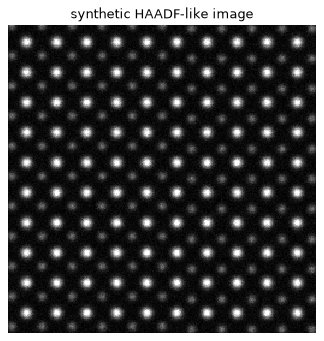

In [2]:
from polarmap import synthetic

def two_domains(xy):
    up = xy[:, 0] < 128
    return np.where(up[:, None], [[0.3, -1.2]], [[-0.3, 1.2]])

s = synthetic.perovskite_100(shape=(256, 256), a=25.0, displacement=two_domains,
                             dose=300, noise_sigma=0.01, seed=1, sampling=0.016)
image, sampling = s.image, s.sampling
fig, ax = plt.subplots(figsize=(5, 5))
plotting.show_image(ax, image); ax.set_title("synthetic HAADF-like image"); ax.axis("off");

## 1. Reference columns

Local maxima with `min_distance` close to the A–A spacing (25 px) pick only the
bright A columns; a 2-D Gaussian fit refines each position.

100 A columns refined


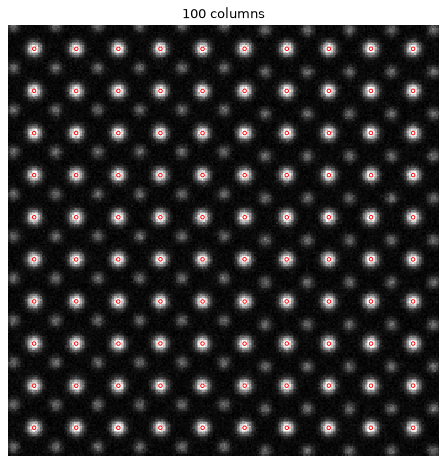

In [3]:
seeds = pm.detect_peaks(image, min_distance=22, threshold_rel=0.2, exclude_border=5)
A, fit = pm.refine_gaussian(image, seeds, box=8, return_params=True)
A = A[fit["success"]]
print(f"{len(A)} A columns refined")
plotting.plot_columns(image, A);

## 2. Lattice vectors and complete cages

v1 = [ 2.5001e+01 -3.0000e-03]  v2 = [-7.0000e-03  2.4998e+01]


81 displacement vectors


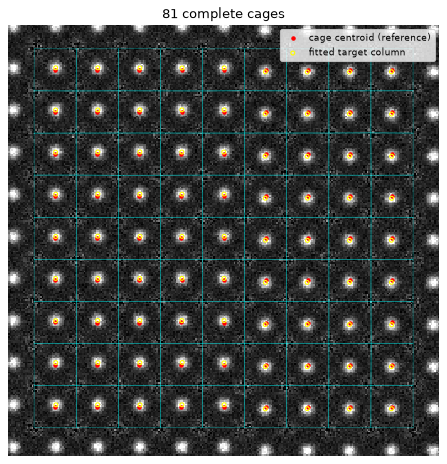

In [4]:
v1, v2 = pm.estimate_lattice_vectors(A)
print("v1 =", np.round(v1, 3), " v2 =", np.round(v2, 3))
field = pm.measure_cage_displacement(image, A, v1, v2)
print(f"{len(field)} displacement vectors")
plotting.plot_cages(field, A);

## 3. Compare with the ground truth

In [5]:
from scipy.spatial import KDTree

_, idx = KDTree(s.target_ideal).query(field.reference_xy)
error_pm = (np.column_stack([field.u, field.v]) - s.displacement[idx]) * sampling * 1e3
print(f"mean error  (x, y): {error_pm.mean(axis=0).round(2)} pm")
print(f"RMS error   (x, y): {np.sqrt((error_pm ** 2).mean(axis=0)).round(2)} pm")
print(f"true |d| = {np.hypot(0.3, 1.2) * sampling * 1e3:.1f} pm")

mean error  (x, y): [0.18 0.06] pm
RMS error   (x, y): [1.18 1.02] pm
true |d| = 19.8 pm


The errors are a small fraction of the displacement and have no systematic
bias. Change `dose` (smaller = noisier) or the column widths in
`synthetic.perovskite_100` to see how the precision depends on the imaging
conditions.

## 4. Figures and statistics

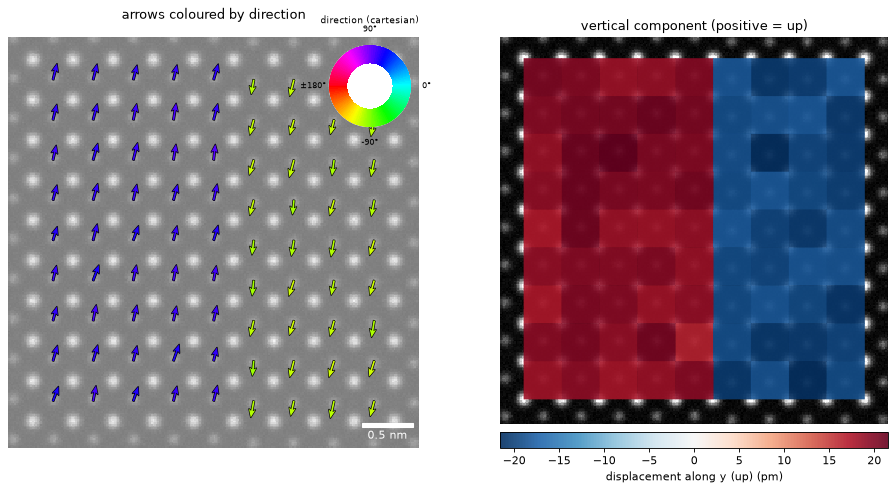

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plotting.plot_displacement_vectors(field, image, ax=axes[0], sampling=sampling,
                                   scale=8, scalebar_nm="auto",
                                   title="arrows coloured by direction")
plotting.plot_displacement_map(field, "v", ax=axes[1], image=image, sampling=sampling,
                               colorbar_location="bottom",
                               title="vertical component (positive = up)")
fig.tight_layout()

Displacement descriptors (n = 81, 0 excluded as outliers)
  magnitude |d| (pm): mean 19.9  median 19.8  std 1.0  MAD 0.8  min 17.2  max 22.4
  orientation (cartesian, deg): circular mean 70.8  circular std 119.9  (R = 0.11)


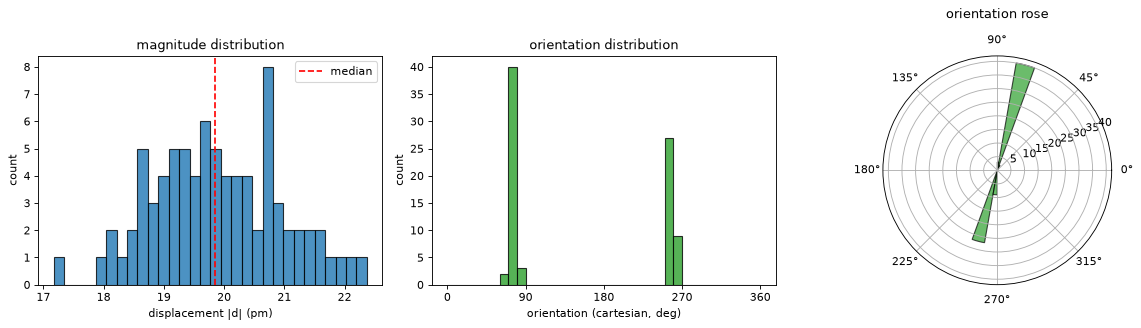

In [7]:
fig, axes, desc = plotting.plot_displacement_statistics(field, sampling)
print(pm.format_descriptors(desc))